# Advertising Spend and Product Sales Prediction

Explore the classic Advertising dataset and compare regression models that predict `Sales` from TV, Radio, and Newspaper advertising spend.

**Source:** [Advertising Dataset — Kaggle](https://www.kaggle.com/datasets/ashydv/advertising-dataset). The downloaded file is `data/advertising.csv` (200 observations, 3 advertising channels, and the sales target).

**Scope and limitations:** the CSV contains no dates, campaign identifiers, currency/unit definitions, or experimental-design metadata. Treat the values as source units and the findings as associations in this small dataset, not proof that changing a channel's budget causes the predicted sales change. Results are evaluated on a reproducible random holdout split.

## 1. Imports and data location

This lookup supports running from this project folder or its parent `DATA SCIENCE` folder.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 110

data_candidates = [
    Path.cwd() / "data",
    Path.cwd().parent / "data",
    Path.cwd() / "Sales Prediction" / "data",
]
data_dir = next((path for path in data_candidates if path.is_dir()), None)
if data_dir is None:
    raise FileNotFoundError("Could not find the data/ folder. Run from Sales Prediction/ or DATA SCIENCE/.")
data_path = data_dir / "advertising.csv"
if not data_path.is_file():
    raise FileNotFoundError(f"Expected Kaggle CSV was not found: {data_path}")
print(f"Dataset: {data_path.resolve()}")

Dataset: C:\Users\Sreeyakeshrajan_T\OneDrive\Desktop\OIBSIP\DATA SCIENCE\Sales Prediction\data\advertising.csv


## 2. Load and inspect the data

Check dimensions, column names, data types, missing values, duplicates, and descriptive statistics before analysis.

In [2]:
raw = pd.read_csv(data_path)
raw.columns = raw.columns.str.strip()
print(f"Shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
print("Columns:", raw.columns.tolist())
display(raw.head())
print("\nData types:")
display(raw.dtypes.rename("dtype").to_frame())
print("\nMissing values:")
display(raw.isna().sum().rename("missing_count").to_frame())
print(f"\nExact duplicate rows: {raw.duplicated().sum()}")
print("\nDescriptive statistics:")
display(raw.describe().T.round(2))

Shape: 200 rows x 4 columns
Columns: ['TV', 'Radio', 'Newspaper', 'Sales']


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9



Data types:


,dtype
TV,float64
Radio,float64
Newspaper,float64
Sales,float64



Missing values:


,missing_count
TV,0
Radio,0
Newspaper,0
Sales,0



Exact duplicate rows: 0

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.04,85.85,0.7,74.38,149.75,218.82,296.4
Radio,200.0,23.26,14.85,0.0,9.98,22.90,36.52,49.6
Newspaper,200.0,30.55,21.78,0.3,12.75,25.75,45.10,114.0
Sales,200.0,15.13,5.28,1.6,11.00,16.00,19.05,27.0


## 3. Validate analysis columns

The source schema is expected to contain numeric `TV`, `Radio`, `Newspaper`, and `Sales`. Coerce values to numeric, remove exact duplicates, and exclude rows with missing/invalid values or negative spend/target amounts. The notebook prints each removal count so cleaning is auditable.

In [3]:
feature_columns = ["TV", "Radio", "Newspaper"]
target_column = "Sales"
required_columns = feature_columns + [target_column]
missing_columns = set(required_columns) - set(raw.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

df = raw[required_columns].copy()
for column in required_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

duplicates_removed = int(df.duplicated().sum())
invalid_rows = int(df[required_columns].isna().any(axis=1).sum())
negative_rows = int((df[feature_columns + [target_column]] < 0).any(axis=1).sum())
df = df.drop_duplicates().dropna(subset=required_columns)
df = df.loc[(df[feature_columns + [target_column]] >= 0).all(axis=1)].reset_index(drop=True)

print(f"Duplicate rows removed: {duplicates_removed}")
print(f"Rows with missing/unparseable values before cleaning: {invalid_rows}")
print(f"Rows with negative spend/sales before cleaning: {negative_rows}")
print(f"Rows retained: {len(df)} of {len(raw)}")
display(df.describe().T.round(2))

Duplicate rows removed: 0
Rows with missing/unparseable values before cleaning: 0
Rows with negative spend/sales before cleaning: 0
Rows retained: 200 of 200


,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.04,85.85,0.7,74.38,149.75,218.82,296.4
Radio,200.0,23.26,14.85,0.0,9.98,22.90,36.52,49.6
Newspaper,200.0,30.55,21.78,0.3,12.75,25.75,45.10,114.0
Sales,200.0,15.13,5.28,1.6,11.00,16.00,19.05,27.0


## 4. Pairplot of all features and target

The pairplot shows each variable's distribution and every pairwise relationship, including Sales against each channel.

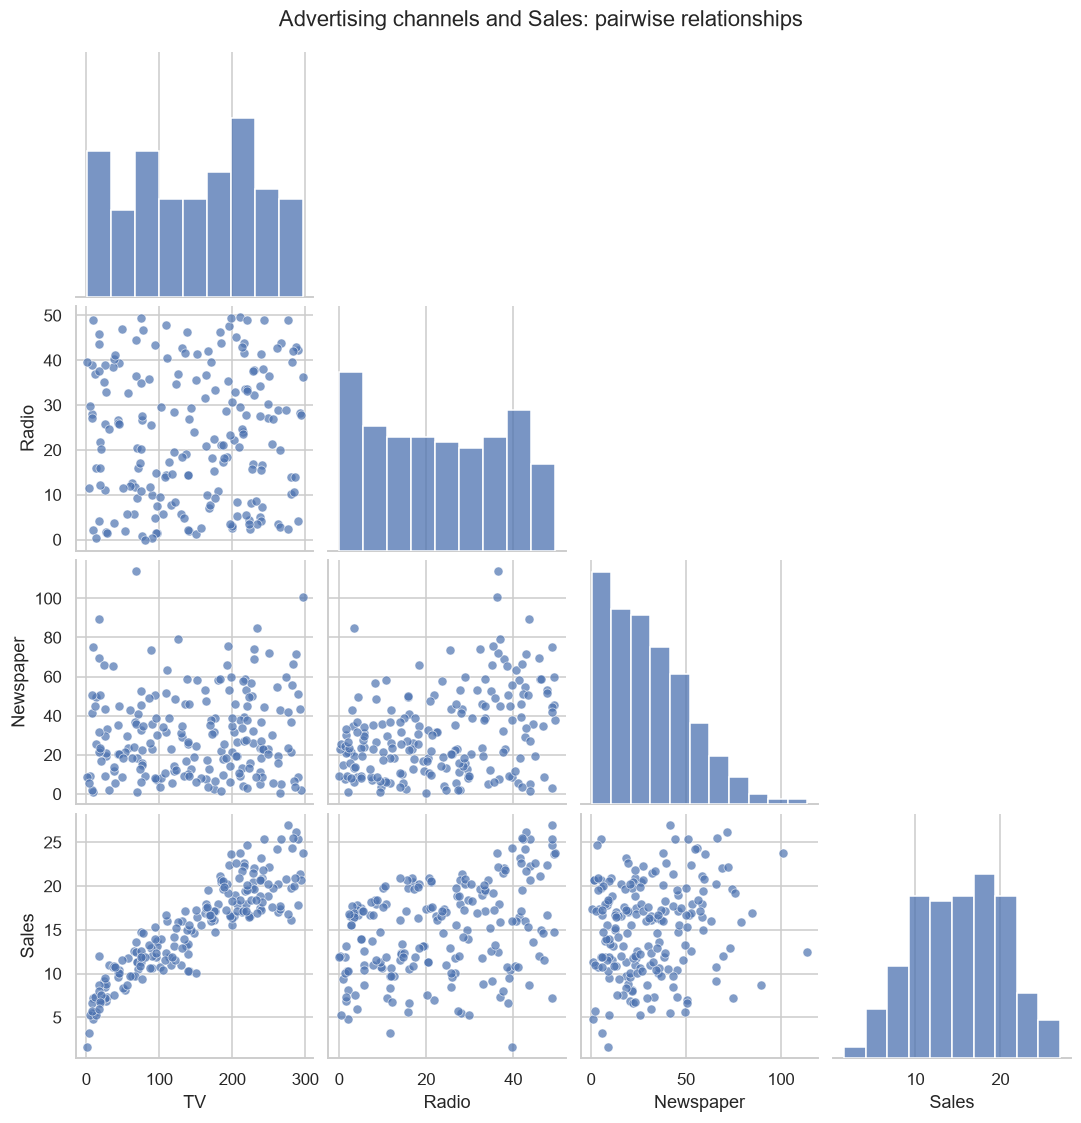

In [4]:
pair_grid = sns.pairplot(df[required_columns], diag_kind="hist", corner=True,
                         plot_kws={"alpha": 0.7, "s": 35})
pair_grid.fig.suptitle("Advertising channels and Sales: pairwise relationships", y=1.02)
plt.show()

## 5. Sales versus each advertising channel

Separate scatter plots make the relationship and spread for each medium easier to inspect.

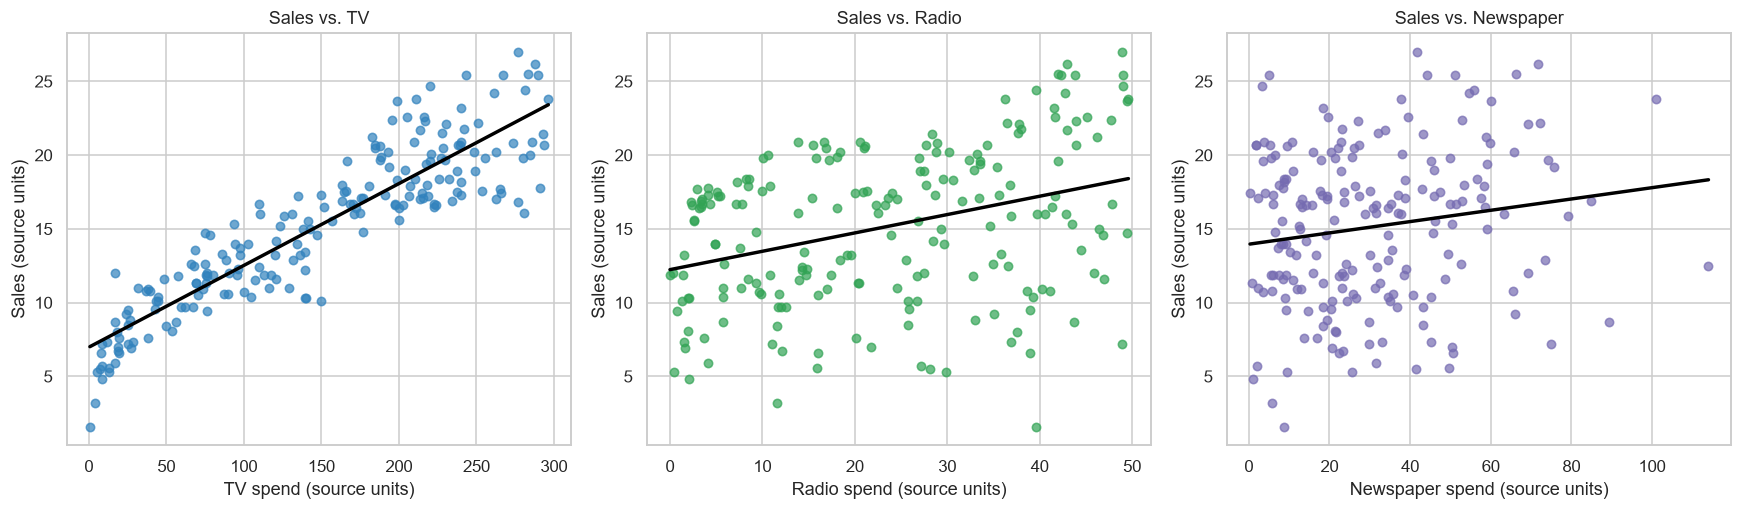

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
colors = {"TV": "#3182bd", "Radio": "#31a354", "Newspaper": "#756bb1"}
for ax, channel in zip(axes, feature_columns):
    sns.regplot(data=df, x=channel, y=target_column, ci=None,
                scatter_kws={"alpha": 0.7, "s": 30}, line_kws={"color": "black"},
                color=colors[channel], ax=ax)
    ax.set(title=f"Sales vs. {channel}", xlabel=f"{channel} spend (source units)", ylabel="Sales (source units)")
plt.tight_layout()
plt.show()

**Observation prompt:** compare the direction, apparent linearity, and scatter around each fitted line. These one-channel views do not account for the other two advertising channels.

## 6. Correlation matrix

The matrix quantifies pairwise linear association. A correlation with Sales is not an independent effect because advertising channels can be correlated with one another.

,TV,Radio,Newspaper,Sales
TV,1.000,0.055,0.057,0.901
Radio,0.055,1.000,0.354,0.350
Newspaper,0.057,0.354,1.000,0.158
Sales,0.901,0.350,0.158,1.000


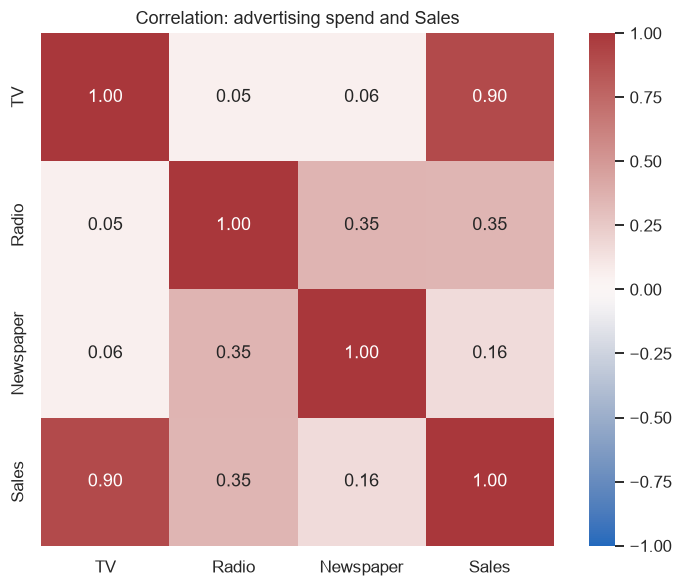

In [6]:
correlation = df[required_columns].corr()
display(correlation.round(3))
plt.figure(figsize=(7, 5.5))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True)
plt.title("Correlation: advertising spend and Sales")
plt.tight_layout()
plt.show()

## 7. Train/test split and regression models

Hold out 20% of observations using a fixed seed. Compare a Linear Regression baseline to a degree-2 Polynomial Regression pipeline and a Random Forest Regressor. Scaling is fit within the training pipeline to avoid test-data leakage. All models use the same split.

In [7]:
X = df[feature_columns]
y = df[target_column]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Training observations: {len(X_train)} | Test observations: {len(X_test)}")

models = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Polynomial Regression (degree 2)": make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        StandardScaler(),
        LinearRegression(),
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
}

fitted_models = {}
predictions = {}
metric_rows = []
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    fitted_models[model_name] = model
    predictions[model_name] = y_pred
    metric_rows.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
    })

results = pd.DataFrame(metric_rows).set_index("Model").sort_values("RMSE")
display(results.round(4))

Training observations: 160 | Test observations: 40


,MAE,RMSE,R2
Model,,,
Random Forest,0.8781,1.1795,0.9550
Polynomial Regression (degree 2),0.9034,1.2011,0.9533
Linear Regression,1.2748,1.7052,0.9059


## 8. Evaluate the models

MAE and RMSE are reported in the target's source units; lower values indicate smaller errors. RMSE penalizes large errors more. R² compares predictions to a constant-mean baseline and can be negative. Select the best model by the lowest held-out RMSE.

Best model by test RMSE: Random Forest


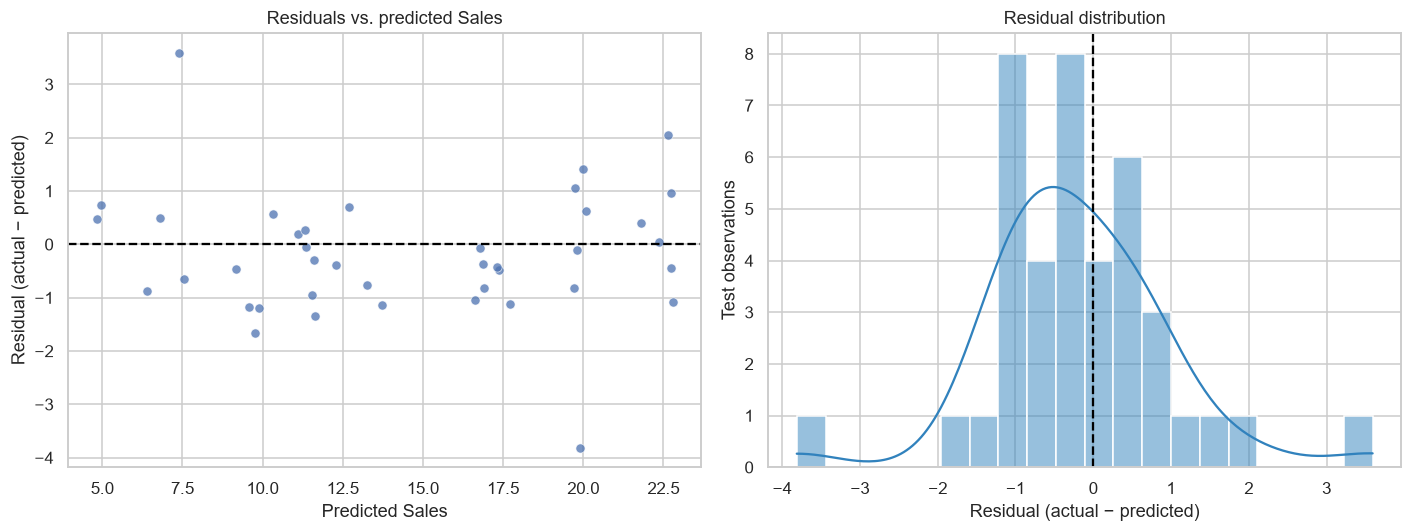

In [8]:
best_model_name = results.index[0]
best_model = fitted_models[best_model_name]
best_predictions = predictions[best_model_name]
residuals = y_test.to_numpy() - best_predictions
print(f"Best model by test RMSE: {best_model_name}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=best_predictions, y=residuals, ax=axes[0], alpha=0.75)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set(title="Residuals vs. predicted Sales", xlabel="Predicted Sales", ylabel="Residual (actual − predicted)")
sns.histplot(residuals, bins=20, kde=True, ax=axes[1], color="#3182bd")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(title="Residual distribution", xlabel="Residual (actual − predicted)", ylabel="Test observations")
plt.tight_layout()
plt.show()

**Residual interpretation:** a roughly pattern-free cloud centered around zero is consistent with less systematic error. Curvature, funnels, or clusters can indicate model misspecification or unequal error spread. A small holdout sample makes visual conclusions uncertain.

## 9. Which channel has the highest estimated impact?

Use the multivariable Linear Regression coefficients. Because all three spend inputs are measured in the same source units, each coefficient estimates the model's change in predicted Sales for one additional spend unit in that channel, holding the other channels fixed. This is an association from a fitted model, not a causal claim. Compare absolute magnitudes for strength and retain coefficient signs for direction.

,estimated_sales_change_per_spend_unit
Radio,0.1009
TV,0.0545
Newspaper,0.0043


By absolute multivariable linear coefficient, Radio has the largest estimated association with Sales (+0.1009 Sales units per spend unit; positive).


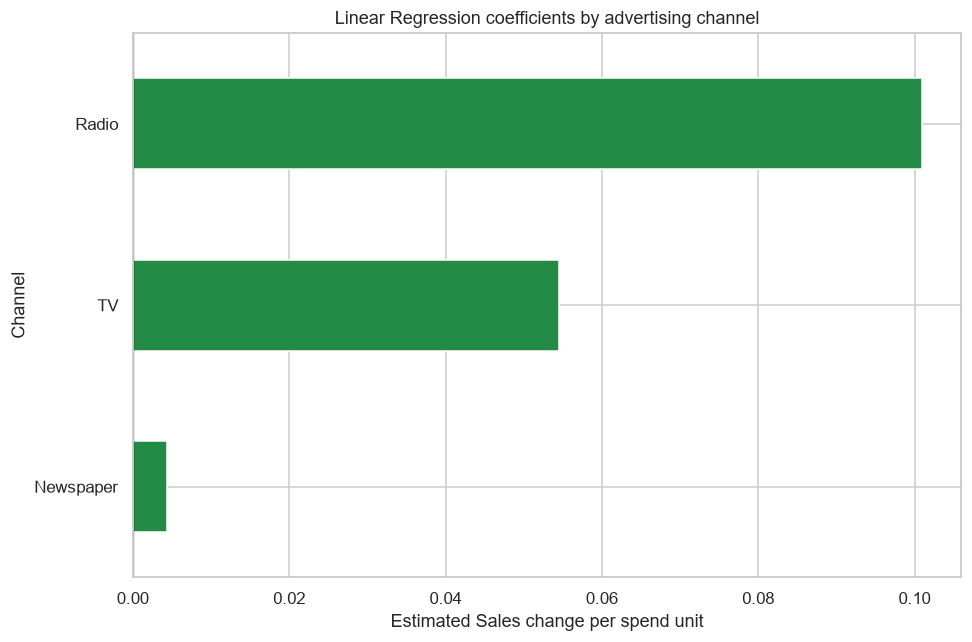

In [9]:
linear_model = fitted_models["Linear Regression"]
linear_regressor = linear_model.named_steps["linearregression"]
linear_scaler = linear_model.named_steps["standardscaler"]
coefficients = pd.Series(
    linear_regressor.coef_ / linear_scaler.scale_,
    index=feature_columns,
    name="estimated_sales_change_per_spend_unit",
).sort_values(key=np.abs, ascending=False)
display(coefficients.to_frame().round(4))

impact_channel = coefficients.abs().idxmax()
impact_direction = "positive" if coefficients[impact_channel] >= 0 else "negative"
print(
    f"By absolute multivariable linear coefficient, {impact_channel} has the largest estimated "
    f"association with Sales ({coefficients[impact_channel]:+.4f} Sales units per spend unit; {impact_direction})."
)
ax = coefficients.sort_values().plot(kind="barh", color=["#d95f0e" if value < 0 else "#238b45" for value in coefficients.sort_values()])
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Linear Regression coefficients by advertising channel", xlabel="Estimated Sales change per spend unit", ylabel="Channel")
plt.tight_layout()
plt.show()

## 10. Reproducible summary

These statements are calculated from the cleaned source and held-out evaluation.

In [10]:
best_metrics = results.loc[best_model_name]
print(f"Cleaned data: {len(df)} observations; train/test split: {len(X_train)}/{len(X_test)}.")
print(f"Best holdout RMSE: {best_model_name} ({best_metrics['RMSE']:.4f}).")
print(f"Its test metrics are MAE={best_metrics['MAE']:.4f}, RMSE={best_metrics['RMSE']:.4f}, R²={best_metrics['R2']:.4f}.")
print(f"Largest absolute Linear Regression coefficient: {impact_channel} ({coefficients[impact_channel]:+.4f}).")
print("Treat the channel coefficient as a conditional association in this dataset, not proof of causal advertising impact.")

Cleaned data: 200 observations; train/test split: 160/40.
Best holdout RMSE: Random Forest (1.1795).
Its test metrics are MAE=0.8781, RMSE=1.1795, R²=0.9550.
Largest absolute Linear Regression coefficient: Radio (+0.1009).
Treat the channel coefficient as a conditional association in this dataset, not proof of causal advertising impact.
